In [15]:
# 1. Load and Prepare the Data
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\ML-Linear Regression-8\\linear regression\\advertising.csv")

# Define predictors and target
#X - predictors or independent variables or features
X = df[['TV', 'Radio', 'Newspaper']]
#y is tearget variable or depedent variable or response 
y = df['Sales']

# Train-test split
#splits data into training nd testing sets
#X_train and y_train : 80% of the data used to train the model
#X_test and y_test : 20% of the data used to evaluate the model
#random_state=42 ensures reproducibility - the same split every time you run it.
#X_train - feature values used to train the model
#X_test - feature values used to evaluate the model
#y_train - actual outcomes used to teach the model
#y_test - actual outcomes used to assess predictions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#why to split the data?
# prevent overfitting 
 # if you train and test on same data, model might just memorize it
  # that leads to poor generalization - model performs on training data, but bad predictions on new data
#model evaluation is IMP
   # compare different model 
   # metrics like RMSE, R^2

In [16]:
# Build the Multiple Linear Regression Model using statsmodels
#adds an intercept term to the feautre matrix
#to ensure the regression equation take the form - y = B0+B1x1+B2x2+.....+Bnxn+e
X_train_sm = sm.add_constant(X_train)
#OLS - Ordinary Least Squares - core method for linear regression
model_mlr = sm.OLS(y_train, X_train_sm).fit()
#fit() - estimates the coefficients (B's) 
print(model_mlr.summary())

#Key Outputs:
#R²: Proportion of variance explained
#Adjusted R²: Penalizes for adding irrelevant predictors
#p-values: Significance of each predictor
#Confidence intervals: Range of plausible coefficient values

#Metrics
#R^2 = 0.900 - interpret -- 90% of variance in Sales is explained by the model - strong fit
#Adj R^2 - 0.89 - interpret -- adjusted for number of predictors - still very strong

#Coefficients
#const - 4.7141 - baseline sales when all media spend is zero
#TV = 0.0545 - every unit increases in TV spend increases sales by - 0.055
# diff of newspaper vs TV and Radio

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     468.7
Date:                Wed, 27 Aug 2025   Prob (F-statistic):           8.51e-78
Time:                        19:56:24   Log-Likelihood:                -305.78
No. Observations:                 160   AIC:                             619.6
Df Residuals:                     156   BIC:                             631.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7141      0.352     13.407      0.0

In [17]:
#3. Residual Diagnostics


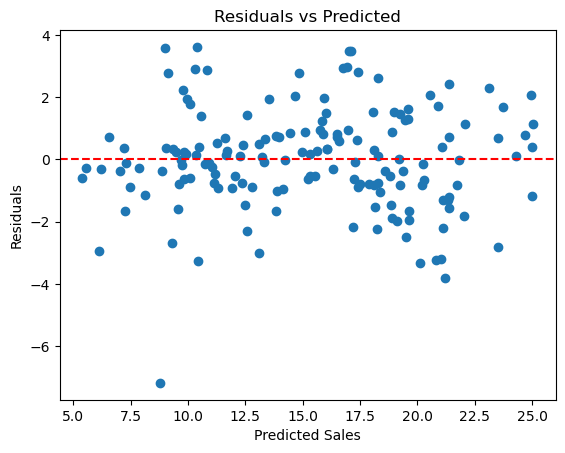

In [18]:
#Residuals vs Predicted
y_pred_train = model_mlr.predict(X_train_sm)
#Residuals = actual -  predicted
residuals = model_mlr.resid

plt.scatter(y_pred_train, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()

#the below graph show hoow far off the model was for each training point
#each dot represents = one training observation
#generates the predicted values of the target variable 
#interpret
#residuals appear fairly evenly distributed around the zero line
#model is reasonably well fittteed

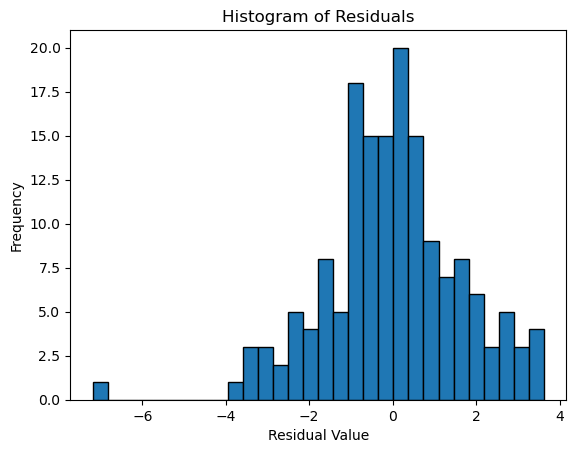

In [19]:
#Histogram of Residuals
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.show()

#inspecting the distribution of residuals to evaluate how well your regression model meets the normality
#the distribution is centered around zero, but slighlty left skewed - meaning there are more negative residuals than postive ones
#peak near zero suggests most predictions are close to actual values 
#no extreme outliers

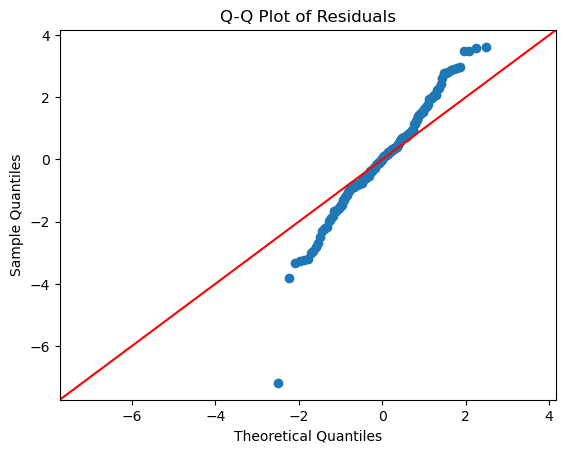

In [20]:
#Q-Q Plot
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()
#Q-Q plot compares te quanttiles off residuals against quantiles of normal distribution so if residuals are normally distributed, the points should fall
#approx. along with diagonal reference line

In [21]:
#4. Check for Multicollinearity (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
#used for quantify multicolinearity

X_vif = sm.add_constant(X_train)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
#initializing a DataFrame to store feature names
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
#calculates VIF for each column in X_vif
print(vif_data)

#VIF
#VIF<5 : generally safe
#VIF>5-10: potential multicollinearity
#VIF>10: multicollinearity (coefficients may be unstable)

#TV -  1.00 - no multicollinearity - TV is independent of other features
#Radio - 1.18 - very low VIF - safe
#News paper - 1.18 - also good - no strong correlation with other predictors

     Feature       VIF
0      const  7.207025
1         TV  1.002915
2      Radio  1.180305
3  Newspaper  1.177309


In [22]:
#5. Feature Selection & Elimination
X_reduced = X_train[['TV', 'Radio']]  # Drop Newspaper if p-value is high
X_reduced_sm = sm.add_constant(X_reduced)
model_reduced = sm.OLS(y_train, X_reduced_sm).fit()
print(model_reduced.summary())

#R^2 = 0.900...90% of variance in sales explained - same as full model
#Adj R^2 - 0.899 - adjsted for no.of predictors - still very strong

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     705.7
Date:                Wed, 27 Aug 2025   Prob (F-statistic):           3.43e-79
Time:                        19:56:25   Log-Likelihood:                -305.98
No. Observations:                 160   AIC:                             618.0
Df Residuals:                     157   BIC:                             627.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7914      0.328     14.606      0.0

In [23]:
#Final Model Evaluation on Test Set
X_test_sm = sm.add_constant(X_test[['TV', 'Radio']])  # Use reduced features
y_pred_test = model_reduced.predict(X_test_sm)

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_test)
print(f"Test R² Score: {r2:.3f}")

#R^2 - measures how well the model explains variance in unseen data
#model explains 90.8% of the variance in Sales on the test set
#slightly better than training R^2 (0.9000) - suggests the model is not overfitting 

Test R² Score: 0.908


In [ ]:
#feature elimination (dropping newspaper) 
#consistent R^2 across train and test set --> model is stable and generalizes well
#